In [ ]:
import pandas as pd

df_book_id = pd.read_csv("/content/drive/MyDrive/final_project/goodreads_books.csv")

print(df_book_id .head(15))

                                    Title          ISBN  \
0                           Summer Story   9.780690e+12   
1                    The Lake of Darkness  9.780376e+12   
2          Beyond the Blue Event Horizon   9.780345e+12   
3                       St. Peter's Fair   9.780446e+12   
4                               Twice Shy  9.780593e+12   
5                   The Door in the Hedge  9.780698e+12   
6                     Moo, Baa, La La La!  9.780690e+12   
7                       Pawn of Prophecy   9.780345e+12   
8                        Pacific Vortex!   9.780553e+12   
9                  The One Minute Manager  9.780061e+12   
10                              Christine  9.782253e+12   
11                                  Proof  9.780571e+12   
12           Dragons of Autumn Twilight    9.780787e+12   
13                        The Bone People  9.780330e+12   
14  Books of Blood: Volumes One to Three   9.780425e+12   

                                    Goodreads Book ID  

In [ ]:
import requests
from bs4 import BeautifulSoup
import csv
import time
import random
import json
import re
import datetime

headers = {
    "User-Agent": "Mozilla/5.0"
}

def get_goodreads_metadata(book_id):
    url = f"https://www.goodreads.com/book/show/{book_id}"
    try:
        response = requests.get(url, headers=headers)
        if response.status_code != 200:
            print(f"Failed to fetch {url}")
            return None

        soup = BeautifulSoup(response.text, "html.parser")
        with open('pretty_html.html', 'w', encoding='utf-8') as file:
            file.write(soup.prettify())

        # Title (working)
        title_tag = soup.find("h1", {"data-testid": "bookTitle"})
        title = title_tag.get_text(strip=True) if title_tag else "Title not found"

        # Series Title and Series Release Number (working)
        series_tag = soup.find("h3", {"class": "Text Text__title3 Text__italic Text__regular Text__subdued"})

        if series_tag:
            series_text = series_tag.get_text(strip=True)
            # Split on the last '#' to separate title and number if possible
            if '#' in series_text:
                series_title, series_release_number = series_text.rsplit('#', 1)
                series_title = series_title.strip()
                series_release_number = series_release_number.strip()
            else:
                series_title = series_text.strip()
                series_release_number = "N/A"
        else:
            series_title = "Standalone"
            series_release_number = "N/A"

        # Authors (working)
        authors = [author.get_text(strip=True) for author in soup.find("span", {"class": "ContributorLink__name"})]

        # Publisher and Publication Date (not working)
        #publication_info_tag = soup.find("p", {"data-testid": "publicationInfo"})
        #publication_info = publication_info_tag.get_text(strip=True) if publication_info_tag else "Publication info not found"
        #publisher = publication_info.split(',')[-1].strip() if ',' in publication_info else "Publisher not found"
        #publication_date = ','.join(publication_info.split(',')[:-1]).strip() if ',' in publication_info else "Publication date not found"

        script_p_tag = soup.find("script", {"id": "__NEXT_DATA__", "type": "application/json"})
        if not script_p_tag:
            print("Error: Script tag with JSON data not found")
            return None

        json_data_p = json.loads(script_p_tag.string)
        apollo_state = json_data_p['props']['pageProps']['apolloState']

        # Find the book key (usually starts with 'Book:')
        book_data = None
        for key, value in apollo_state.items():
            if key.startswith("Book:"):
                book_data = value
                break

        if not book_data:
            print(f"No Book data found for Goodreads ID {goodreads_id}")
            return None, None

        # Extract publisher and publication date
        details = book_data.get('details', {})
        publisher = details.get('publisher', 'Publisher not found')
        publication_time = details.get('publicationTime', None)

        if publication_time:
            publication_date = datetime.datetime.fromtimestamp(publication_time / 1000).strftime('%Y-%m-%d')
        else:
            publication_date = "Publication date not found"

        #Language (working)
        script_tag = soup.find('script', {'type': 'application/ld+json'})
        json_data = json.loads(script_tag.string)
        language = json_data.get('inLanguage', None)

        # Description (working)
        description_tag = soup.find("div", {"data-testid": "description"})
        description = description_tag.get_text(strip=True) if description_tag else "Description not found"

        # Number of Pages and Format (working)
        pages_format_tag = soup.find("p", {"data-testid": "pagesFormat"})
        pages_format = pages_format_tag.get_text(strip=True) if pages_format_tag else "Pages and format not found"
        num_pages = pages_format.split(' ')[0] if pages_format else "N/A"
        format_ = ' '.join(pages_format.split(' ')[2:]) if pages_format else "Format not found"

        # Genres (working)
        genres = [genre.get_text(strip=True) for genre in soup.select('a[href*="/genres/"]')]

        # Rating Score, Number of Ratings, and Number of Reviews (working)
        rating_score_tag = soup.find("div", {"class": "RatingStatistics__rating"})
        rating_score = rating_score_tag.get_text(strip=True) if rating_score_tag else "No rating"
        num_ratings_tag = soup.find("span", {"data-testid": "ratingsCount"})
        num_ratings = num_ratings_tag.get_text(strip=True).replace('ratings', '').strip() if num_ratings_tag else "0"
        num_reviews_tag = soup.find("span", {"data-testid": "reviewsCount"})
        num_reviews = num_reviews_tag.get_text(strip=True).replace('reviews', '').strip() if num_reviews_tag else "0"

        # Current Readers and Want to Read (working)
        current_readers_tag = soup.find("div", {"data-testid": "currentlyReadingSignal"})
        current_readers = current_readers_tag.get_text(strip=True).replace('people are currently reading', '').strip() if current_readers_tag else "0"
        want_to_read_tag = soup.find("div", {"data-testid": "toReadSignal"})
        want_to_read = want_to_read_tag.get_text(strip=True).replace('people want to read', '').strip() if want_to_read_tag else "0"
        #make sure to cleaning it up later to become number - if 1k then transform to 1000

        # Get the top 3 comments
        comments = get_top_comments(url)

        return {
            "Title": title,
            "Series Title": series_title,
            "Series Release Number": series_release_number,
            "Authors": ', '.join(authors),
            "Publisher": publisher,
            "Publication Date": publication_date,
            "Language": language,
            "Description": description,
            "Number of Pages": num_pages,
            "Format": format_,
            "Genres": ', '.join(genres),
            "Rating Score": rating_score,
            "Number of Ratings": num_ratings,
            "Number of Reviews": num_reviews,
            "Current Readers": current_readers,
            "Want to Read": want_to_read,
            "Comment 1": comments[0] if len(comments) > 0 else "",
            "Comment 2": comments[1] if len(comments) > 1 else "",
            "Comment 3": comments[2] if len(comments) > 2 else "",
            "Comment 4": comments[3] if len(comments) > 3 else ""
        }

    except Exception as e:
        print(f"Error scraping {url}: {e}")
        return None

def get_top_comments(url, max_comments=4):
    try:
        response = requests.get(url, headers=headers)
        if response.status_code != 200:
            print(f"Failed to fetch {url}")
            return []

        soup = BeautifulSoup(response.text, 'html.parser')

        review_divs = soup.find_all('section', {'class': 'ReviewText'}, limit=max_comments)
        comments = []

        for div in review_divs:
            full_text = div.get_text(strip=True)
            comments.append(full_text)

        return comments
    except Exception as e:
        print(f"Error scraping {url}: {e}")
        return []

with open("/content/drive/MyDrive/final_project/book_metadata_and_comments.csv", "w", newline='', encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["Title", "Series Title", "Series Release Number", "Authors", "Publisher", "Publication Date", "Language", "Description",
                     "Number of Pages", "Format", "Genres", "Rating Score", "Number of Ratings",
                     "Number of Reviews", "Current Readers", "Want to Read", "Comment 1", "Comment 2", "Comment 3", "Comment 4"])

    for book_id in df_book_id.iloc[:,2]:
        #book id is in the third column of the csv file

        print(f"\nFetching metadata for: {book_id}")
        match = re.match(r"^(\d+)\.", book_id)
        if match:
            goodreads_id = match.group(1)
        metadata = get_goodreads_metadata(book_id)

        if metadata:
            print(f"Metadata found for: {book_id}")
            writer.writerow([metadata["Title"], metadata["Series Title"], metadata["Series Release Number"], metadata["Authors"],
                             metadata["Publisher"], metadata["Publication Date"], metadata["Language"], metadata["Description"],
                             metadata["Number of Pages"], metadata["Format"], metadata["Genres"], metadata["Rating Score"],
                             metadata["Number of Ratings"], metadata["Number of Reviews"], metadata["Current Readers"], metadata["Want to Read"],
                             metadata["Comment 1"], metadata["Comment 2"], metadata["Comment 3"], metadata["Comment 4"]])
        else:
            print(f"Could not find metadata for: {book_id}")
            writer.writerow([book_id] + ["Data not found"] * 18)

        time.sleep(random.uniform(4, 6))  # Respectful delay between requests

print("Metadata scraping completed.")



Streaming output truncated to the last 5000 lines.
Metadata found for: 872333.Blue_Bloods?from_search=true&from_srp=true&qid=W97eSkKLIs&rank=1.blue-bloods

Fetching metadata for: 18749.Half_of_a_Yellow_Sun?from_search=true&from_srp=true&qid=Wd5BK6suQt&rank=1.half-of-a-yellow-sun
Metadata found for: 18749.Half_of_a_Yellow_Sun?from_search=true&from_srp=true&qid=Wd5BK6suQt&rank=1.half-of-a-yellow-sun

Fetching metadata for: 817791.The_Blind_Side?from_search=true&from_srp=true&qid=x7nzaUwN07&rank=1.the-blind-side
Metadata found for: 817791.The_Blind_Side?from_search=true&from_srp=true&qid=x7nzaUwN07&rank=1.the-blind-side

Fetching metadata for: 30119.Where_the_Sidewalk_Ends?from_search=true&from_srp=true&qid=TZUtEs0ySP&rank=1.the-end
Metadata found for: 30119.Where_the_Sidewalk_Ends?from_search=true&from_srp=true&qid=TZUtEs0ySP&rank=1.the-end

Fetching metadata for: 213753.Life_As_We_Knew_It?from_search=true&from_srp=true&qid=qVN16loGuv&rank=1.life-as-we-knew-it
Metadata found for: 213753.

In [ ]:
import pandas as pd

df_books = pd.read_csv("/content/drive/MyDrive/final_project/book_metadata_and_comments.csv")

df_books.head()

,Title,Series Title,Series Release Number,Authors,Publisher,Publication Date,Language,Description,Number of Pages,Format,Genres,Rating Score,Number of Ratings,Number of Reviews,Current Readers,Want to Read,Comment 1,Comment 2,Comment 3,Comment 4
0,Felicity Saves the Day: A Summer Story,American Girl: Felicity,5,Valerie Tripp,American Girl,1992-07-01,English,Felicity loves summertime on Grand father's pl...,88,Paperback,"Historical Fiction, Childrens, Fiction, Histor...",3.92,"5,569",122,38,793,"It was so great to have Penny come back, and F...","""You are a coward. It's cowardly to break prom...","Ahhh, summertime on a Virginia plantation. So ...",yay penny! love a girl and her animal having a...
1,The Lake of Darkness,Standalone,NaN,Ruth Rendell,Vintage Crime/Black Lizard,2001-09-01,English,Martin Urban is a quiet bachelor with a comfor...,210,Paperback,"Mystery, Fiction, Crime, Thriller, British Lit...",3.77,"1,477",123,89,667,No Good Deed Goes UnpunishedReview of the Arro...,Ruth Rendell is on fine form in this short nov...,I was a bit disappointed by Master of the Moor...,"Martin, an ordinary, middle-class accountant w..."
2,Beyond the Blue Event Horizon,Heechee Saga,2,Frederik Pohl,Ballantine Books,2000-11-07,English,"In Book Two of the Heechee Saga, Robinette Bro...",336,Paperback,"Science Fiction, Fiction, Space Opera, Audiobo...",3.95,"13,686",374,188,"4,226",Beyond the Blue Event Horizon was a solid sequ...,"""The story begins when the hero of Gateway fin...","Uh!Ova knjiga je na momente ODLCNA, originalne...","EnPórtico, aprendimos que la humanidad ha dado..."
3,St. Peter's Fair,Chronicles of Brother Cadfael,4,Ellis Peters,Publisher not found,Publication date not found,English,A pause in the civil war offers Shrewsbury's t...,217,Mass Market Paperback,"Mystery, Historical Fiction, Fiction, Historic...",4.11,"11,240",647,"1,492","2,682","The Fourth Chronicle Of Brother Cadfael, Of Th...",Everybody knows about this fabulous writer of ...,My favorite of this series so far. I loved the...,While the fact that in Ellis Peters'Saint Pete...
4,Twice Shy,Standalone,NaN,Sarah Hogle,G.P. Putnam's Sons,2021-04-06,English,Can you find real love when you've always got ...,302,Paperback,"Romance, Contemporary, Contemporary Romance, F...",3.66,"37,042","6,679",902,65.1k,Attention to the following things:- raindrops ...,good LORD this was sweeti really was unsure go...,Could just about handle how cute this book was...,"well, this story is so sweet that my doctor ju..."


In [ ]:
df_books["Title"].value_counts()[df_books["Title"].value_counts() > 1]
df_books.drop_duplicates(subset='Title', inplace=True)


In [ ]:
df_books.isna().sum()
#series release have many null because some (most) are standalone books - better to do analysis through series title and
#filter by standalone the to do go by series release number being null because some of them didnt fetch it right

#I am not sure what to do with the missing values

#variables we probably wont use: series release number, description, number of pages (maybe for some analysis like people prefer shorter books),
#format
#Also, fix up the columns names to be easy to identify (janitor package or something-I miss my packages on R)

,0
Title,0
Series Title,0
Series Release Number,1800
Authors,0
Publisher,85
Publication Date,0
Language,16
Description,4
Number of Pages,0
Format,24


In [ ]:
pip install pyjanitor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 4.8 MB/s eta 0:00:00


In [ ]:
import janitor

df_books = df_books.clean_names()


In [ ]:
def convert_to_number(value):
    if isinstance(value, str):
        value = value.lower().replace(',', '')
        if 'k' in value:
            return float(value.replace('k', '').strip()) * 1000
        elif 'm' in value:
            return float(value.replace('m', '').strip()) * 1000000
        elif 'b' in value:
            return float(value.replace('b', '').strip()) * 1000000000
        else:
            return pd.to_numeric(value, errors='coerce')
    return value

df_books['want_to_read'] = df_books['want_to_read'].apply(convert_to_number)
df_books['number_of_ratings'] = df_books['number_of_ratings'].apply(convert_to_number)
df_books['number_of_reviews'] = df_books['number_of_reviews'].apply(convert_to_number)
df_books['current_readers'] = df_books['current_readers'].apply(convert_to_number)
df_books.head()


,title,series_title,series_release_number,authors,publisher,publication_date,language,description,number_of_pages,format,genres,rating_score,number_of_ratings,number_of_reviews,current_readers,want_to_read,comment_1,comment_2,comment_3,comment_4
0,Felicity Saves the Day: A Summer Story,American Girl: Felicity,5,Valerie Tripp,American Girl,1992-07-01,English,Felicity loves summertime on Grand father's pl...,88,Paperback,"Historical Fiction, Childrens, Fiction, Histor...",3.92,5569,122.0,38.0,793.0,"It was so great to have Penny come back, and F...","""You are a coward. It's cowardly to break prom...","Ahhh, summertime on a Virginia plantation. So ...",yay penny! love a girl and her animal having a...
1,The Lake of Darkness,Standalone,NaN,Ruth Rendell,Vintage Crime/Black Lizard,2001-09-01,English,Martin Urban is a quiet bachelor with a comfor...,210,Paperback,"Mystery, Fiction, Crime, Thriller, British Lit...",3.77,1477,123.0,89.0,667.0,No Good Deed Goes UnpunishedReview of the Arro...,Ruth Rendell is on fine form in this short nov...,I was a bit disappointed by Master of the Moor...,"Martin, an ordinary, middle-class accountant w..."
2,Beyond the Blue Event Horizon,Heechee Saga,2,Frederik Pohl,Ballantine Books,2000-11-07,English,"In Book Two of the Heechee Saga, Robinette Bro...",336,Paperback,"Science Fiction, Fiction, Space Opera, Audiobo...",3.95,13686,374.0,188.0,4226.0,Beyond the Blue Event Horizon was a solid sequ...,"""The story begins when the hero of Gateway fin...","Uh!Ova knjiga je na momente ODLCNA, originalne...","EnPórtico, aprendimos que la humanidad ha dado..."
3,St. Peter's Fair,Chronicles of Brother Cadfael,4,Ellis Peters,Publisher not found,Publication date not found,English,A pause in the civil war offers Shrewsbury's t...,217,Mass Market Paperback,"Mystery, Historical Fiction, Fiction, Historic...",4.11,11240,647.0,1492.0,2682.0,"The Fourth Chronicle Of Brother Cadfael, Of Th...",Everybody knows about this fabulous writer of ...,My favorite of this series so far. I loved the...,While the fact that in Ellis Peters'Saint Pete...
4,Twice Shy,Standalone,NaN,Sarah Hogle,G.P. Putnam's Sons,2021-04-06,English,Can you find real love when you've always got ...,302,Paperback,"Romance, Contemporary, Contemporary Romance, F...",3.66,37042,6679.0,902.0,65100.0,Attention to the following things:- raindrops ...,good LORD this was sweeti really was unsure go...,Could just about handle how cute this book was...,"well, this story is so sweet that my doctor ju..."


In [ ]:
author_counts = df_books['authors'].value_counts()
mean_books_per_author = author_counts.mean()#keeping 368 so use another metrics
common_authors = author_counts[author_counts >= mean_books_per_author]
print(common_authors)


authors
Stephen        King     46
Nora Roberts            33
Terry Pratchett         32
Neil Gaiman             26
Cassandra Clare         19
                        ..
Timothy Zahn             3
Emily Giffin             3
Sandra       Brown       3
Arturo Pérez-Reverte     3
Clive Barker             3
Name: count, Length: 368, dtype: int64


In [ ]:
publi_count = df_books['publisher'].value_counts()
mean_books_per_publi = publi_count.mean()#keeping 209 so use another metrics
common_publi = publi_count[publi_count >= mean_books_per_publi]
print(common_publi)
top_5_publi=common_publi.head(5)
print(top_5_publi)

publisher
Ballantine Books                 92
Vintage                          80
Berkley                          72
Bantam                           59
St. Martin's Press               55
                                 ..
Bloomsbury                        4
Knopf Books for Young Readers     4
New Directions                    4
MysteriousPress.com/Open Road     4
Piatkus                           4
Name: count, Length: 209, dtype: int64
publisher
Ballantine Books      92
Vintage               80
Berkley               72
Bantam                59
St. Martin's Press    55
Name: count, dtype: int64


In [ ]:
df_books['publication_date'] = pd.to_datetime(df_books['publication_date'], errors='coerce')
df_books['publication_year'] = df_books['publication_date'].dt.year.astype('Int64')
df_books['publication_month'] = df_books['publication_date'].dt.month.astype('Int64')
df_books['publication_day'] = df_books['publication_date'].dt.day.astype('Int64')

<Axes: xlabel='publication_year'>

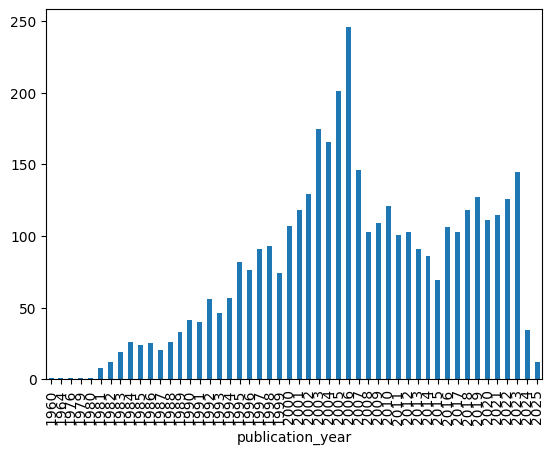

In [ ]:
df_books['publication_year'].value_counts().sort_index().plot(kind='bar')


<Axes: xlabel='publication_year'>

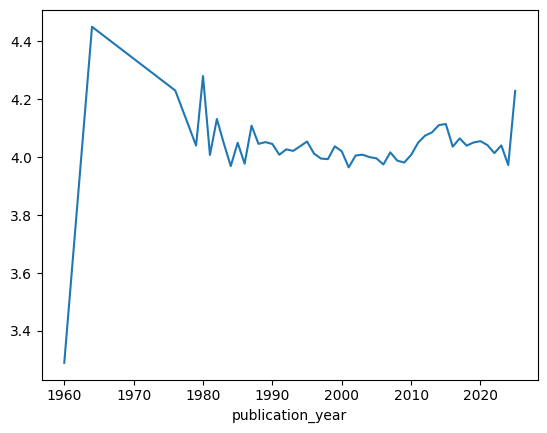

In [ ]:
df_books.groupby('publication_year')['rating_score'].mean().plot(kind='line')
#based on the graph above it is because no books are published before 1980 so that's why of the big jump
#maybe we should shorten down the range. Would this affect analysis? Should we normalize (the data doesnt seems too skewed for me)?


In [ ]:
type(df_books["genres"])
#df_books["genres"]=df_books["genres"].str.split(", ")
df_books["genres"].iloc[2]

np.float64(nan)

In [ ]:
#df_books.to_csv('/content/drive/MyDrive/final_project/cleaned_book_data.csv', index=False)